# Interval-Censored HAL-MLE via Direct FISTA

This notebook demonstrates interval-censored HAL density estimation without EM.

We fit:
- one fixed-`lam` model with `IntervalCensoredFISTAEstimator`
- one Optuna CV-selected model with `IntervalCensoredFISTATuner`

Both use the same interval-censored HAL setup, but optimization is done by first-order proximal updates (FISTA) rather than CVXPY/EM.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from haldensity.censoring import (
    IntervalCensoredFISTAEstimator,
    IntervalCensoredFISTATuner,
    IntervalCensoredProjectedGDEstimator,
    IntervalCensoredProjectedGDTuner,
    interval_censor_inspection_uniform,
    interval_censor_current_status_uniform,
    kl_divergence,
)
from haldensity.utils import TruncatedGMM

np.random.seed(42)

/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 1) Simulate latent event times on [0, 1]
components = [
    {"mean": 0.30, "std": 0.08, "lower": 0.0, "upper": 1.0},
    {"mean": 0.72, "std": 0.06, "lower": 0.0, "upper": 1.0},
]
weights = [0.55, 0.45]
sampler = TruncatedGMM(components=components, weights=weights)

# Smaller sample size for faster experimentation
n = 200
t_event = sampler.generate_samples(n)

# 2) Interval-censor using independent inspection times
ic_df = interval_censor_inspection_uniform(t_event, n_inspections=3, random_state=42)
ic_df.head()

,L,R
0,0.000000,0.438878
1,0.094177,0.697368
2,0.128114,0.761140
3,0.450386,0.926765
4,0.000000,0.443414


In [3]:
# Fit one direct FISTA model with a fixed lambda
fixed_lam = 0.2
fista_fixed = IntervalCensoredFISTAEstimator(
    lam=fixed_lam,
    n_iterations=1200,
    tol=1e-6,
    ll_change_tol=1e-3,
    n_grid_points=350,
    basis_order=0,
    initial_step=1.0,
    max_step=1.0,
    log_frequency=-1,
)
fista_fixed.fit(ic_df, knot_strategy="turnbull")

fixed_res = fista_fixed.get_results()
print({
    "lam": fixed_lam,
    "converged": fixed_res["converged"],
    "n_iterations_run": fixed_res["n_iterations_run"],
    "n_selected_knots": fixed_res["n_selected_knots"],
})

{'lam': 0.2, 'converged': True, 'n_iterations_run': 151, 'n_selected_knots': 33}


In [4]:
# Tune lambda by Optuna CV (direct FISTA objective in each fold)
tuner = IntervalCensoredFISTATuner(
    data=ic_df,
    cv_folds=5,
    random_state=42,
    n_grid_points=300,
    param_overrides={
        "basis_order": [0, 1, 2],
        "lam": {"low": 1e-3, "high": 2e-1, "log": True},
    },
    knot_strategy="turnbull",
    fista_kwargs={
        "n_iterations": 2000,
        "tol": 1e-6,
        "ll_change_tol": 1e-3,
        "initial_step": 1.0,
        "max_step": 1.0,
    },
    silent=False,
)

cv_result = tuner.optimize(n_trials=30)
fista_cv = cv_result.estimator
print("Best params:", cv_result.best_params)
print("Best mean CV incomplete log-lik:", cv_result.metadata["best_metric_value"])

cv_fit_res = fista_cv.get_results()
print({
    "converged": cv_fit_res["converged"],
    "n_iterations_run": cv_fit_res["n_iterations_run"],
    "n_selected_knots": cv_fit_res["n_selected_knots"],
})

Best trial: 20. Best value: 35.1466: 100%|██████████| 30/30 [00:25<00:00,  1.20it/s]


Best params: {'basis_order': 2, 'lam': 0.009005363030463742}
Best mean CV incomplete log-lik: -35.1466342469417
{'converged': True, 'n_iterations_run': 449, 'n_selected_knots': 43}


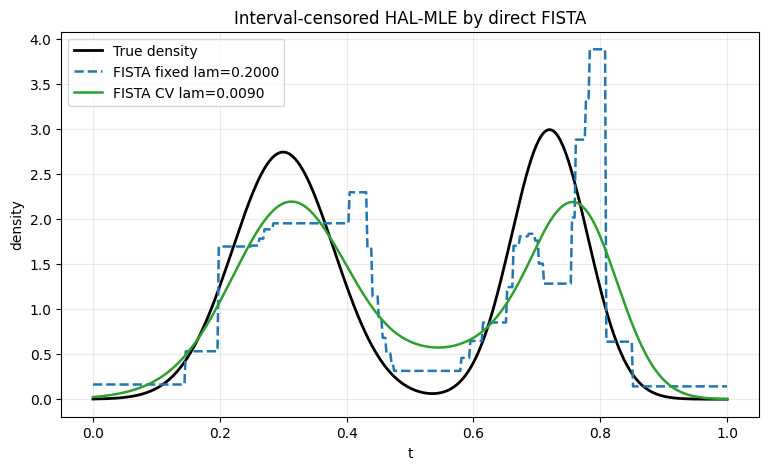

In [5]:
# Compare densities against truth
grid = np.linspace(0.0, 1.0, 500)
true_density = sampler.compute_density(grid)
fixed_density = fista_fixed.get_density_at_points(grid)
cv_density = fista_cv.get_density_at_points(grid)

plt.figure(figsize=(9, 5))
plt.plot(grid, true_density, "k-", lw=2, label="True density")
plt.plot(grid, fixed_density, "tab:blue", lw=1.8, linestyle="--", label=f"FISTA fixed lam={fixed_lam:.4f}")
plt.plot(grid, cv_density, "tab:green", lw=1.8, label=f"FISTA CV lam={cv_result.best_params['lam']:.4f}")
plt.xlabel("t")
plt.ylabel("density")
plt.title("Interval-censored HAL-MLE by direct FISTA")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [6]:
# KL comparison on a dense grid
grid_kl = np.linspace(0.0, 1.0, 2000)
kl_fixed = float(kl_divergence(sampler.compute_density, grid_kl, fista_fixed.get_density_at_points(grid_kl)))
kl_cv = float(kl_divergence(sampler.compute_density, grid_kl, fista_cv.get_density_at_points(grid_kl)))

pd.DataFrame(
    {
        "model": ["FISTA fixed lambda", "FISTA CV lambda"],
        "lambda": [fixed_lam, cv_result.best_params["lam"]],
        "KL(true || estimated)": [kl_fixed, kl_cv],
    }
)

,model,lambda,KL(true || estimated)
0,FISTA fixed lambda,0.200000,0.155048
1,FISTA CV lambda,0.009005,0.102551


## Projected Gradient (L1-Constrained) on Interval-Censored Data

This section uses direct projected gradient descent with an L1-ball constraint (`norm_constraint`) instead of an L1 penalty parameter (`lam`).

In [7]:
# Fixed norm-constraint projected-GD fit
fixed_nc = 6.0
pgd_fixed = IntervalCensoredProjectedGDEstimator(
    norm_constraint=fixed_nc,
    learning_rate=0.05,
    use_nesterov=True,
    n_iterations=2000,
    tol=1e-6,
    ll_change_tol=1e-3,
    n_grid_points=320,
    basis_order=0,
)
pgd_fixed.fit(ic_df, knot_strategy="turnbull")

pgd_fixed_res = pgd_fixed.get_results()
print({
    "norm_constraint": fixed_nc,
    "converged": pgd_fixed_res["converged"],
    "n_iterations_run": pgd_fixed_res["n_iterations_run"],
    "n_selected_knots": pgd_fixed_res["n_selected_knots"],
})

{'norm_constraint': 6.0, 'converged': True, 'n_iterations_run': 148, 'n_selected_knots': 24}


In [8]:
# Tune norm_constraint by Optuna CV for projected-GD
pgd_tuner = IntervalCensoredProjectedGDTuner(
    data=ic_df,
    cv_folds=5,
    random_state=42,
    n_grid_points=300,
    param_overrides={
        "basis_order": [0, 1, 2],
        "norm_constraint": {"low": 1.0, "high": 20.0, "log": True},
    },
    knot_strategy="turnbull",
    pgd_kwargs={
        "learning_rate": 0.05,
        "use_nesterov": True,
        "n_iterations": 2000,
        "tol": 1e-6,
        "ll_change_tol": 1e-3,
    },
    silent=False,
)
pgd_cv_result = pgd_tuner.optimize(n_trials=30)
pgd_cv = pgd_cv_result.estimator
print("Best projected-GD params:", pgd_cv_result.best_params)
print("Best mean CV incomplete log-lik:", pgd_cv_result.metadata["best_metric_value"])

Best trial: 26. Best value: 35.3243: 100%|██████████| 30/30 [00:21<00:00,  1.42it/s]


Best projected-GD params: {'basis_order': 0, 'norm_constraint': 5.607380433938585}
Best mean CV incomplete log-lik: -35.32429053725477


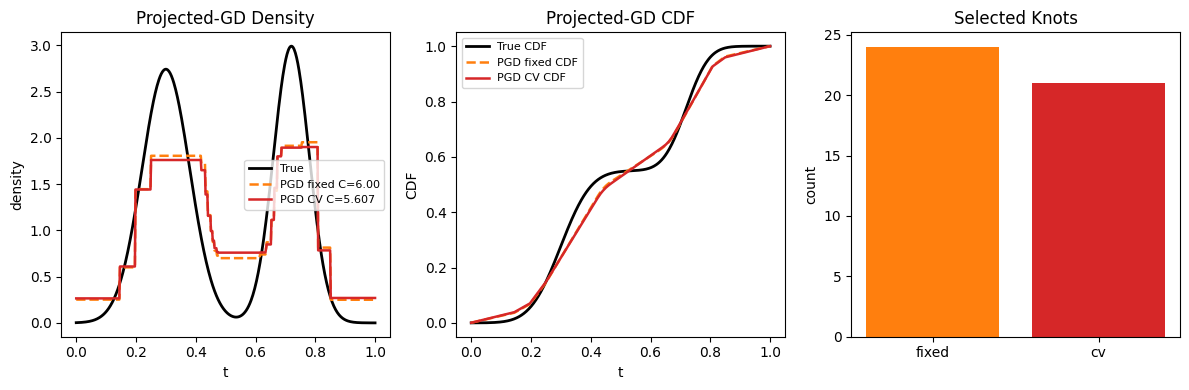

In [9]:
# Extra visualization for projected-GD (interval-inspection data)
pgd_grid = np.linspace(0.0, 1.0, 500)
pgd_true = sampler.compute_density(pgd_grid)
pgd_fixed_density = pgd_fixed.get_density_at_points(pgd_grid)
pgd_cv_density = pgd_cv.get_density_at_points(pgd_grid)

pgd_true_cdf = np.cumsum(pgd_true)
pgd_true_cdf = pgd_true_cdf / pgd_true_cdf[-1]
pgd_fixed_cdf = np.cumsum(pgd_fixed_density)
pgd_fixed_cdf = pgd_fixed_cdf / pgd_fixed_cdf[-1]
pgd_cv_cdf = np.cumsum(pgd_cv_density)
pgd_cv_cdf = pgd_cv_cdf / pgd_cv_cdf[-1]

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(pgd_grid, pgd_true, "k-", lw=2, label="True")
plt.plot(pgd_grid, pgd_fixed_density, "tab:orange", lw=1.8, linestyle="--", label=f"PGD fixed C={fixed_nc:.2f}")
plt.plot(pgd_grid, pgd_cv_density, "tab:red", lw=1.8, label=f"PGD CV C={pgd_cv_result.best_params['norm_constraint']:.3f}")
plt.title("Projected-GD Density")
plt.xlabel("t")
plt.ylabel("density")
plt.legend(fontsize=8)

plt.subplot(1, 3, 2)
plt.plot(pgd_grid, pgd_true_cdf, "k-", lw=2, label="True CDF")
plt.plot(pgd_grid, pgd_fixed_cdf, "tab:orange", lw=1.8, linestyle="--", label="PGD fixed CDF")
plt.plot(pgd_grid, pgd_cv_cdf, "tab:red", lw=1.8, label="PGD CV CDF")
plt.title("Projected-GD CDF")
plt.xlabel("t")
plt.ylabel("CDF")
plt.legend(fontsize=8)

plt.subplot(1, 3, 3)
plt.bar(
    ["fixed", "cv"],
    [pgd_fixed_res["n_selected_knots"], pgd_cv.get_results()["n_selected_knots"]],
    color=["tab:orange", "tab:red"],
)
plt.title("Selected Knots")
plt.ylabel("count")

plt.tight_layout()
plt.show()

## Current-Status Example

Now we repeat direct projected-GD HAL-MLE on current-status interval-censored data (single inspection time per subject).

In [10]:
# Build current-status data from the same latent event-time distribution
cs_df = interval_censor_current_status_uniform(t_event, random_state=7)

# Fixed projected-GD model on current-status
cs_fixed_nc = 6.0
pgd_cs_fixed = IntervalCensoredProjectedGDEstimator(
    norm_constraint=cs_fixed_nc,
    learning_rate=0.05,
    use_nesterov=True,
    n_iterations=2000,
    tol=1e-6,
    ll_change_tol=1e-3,
    n_grid_points=300,
    basis_order=0,
)
pgd_cs_fixed.fit(cs_df, knot_strategy="turnbull")

# CV-tuned projected-GD model on current-status
pgd_cs_tuner = IntervalCensoredProjectedGDTuner(
    data=cs_df,
    cv_folds=5,
    random_state=7,
    n_grid_points=260,
    param_overrides={
        "basis_order": [0, 1, 2],
        "norm_constraint": {"low": 1.0, "high": 20.0, "log": True},
    },
    knot_strategy="turnbull",
    pgd_kwargs={
        "learning_rate": 0.05,
        "use_nesterov": True,
        "n_iterations": 2000,
        "tol": 1e-6,
        "ll_change_tol": 1e-3,
    },
    silent=False,
)
pgd_cs_cv_result = pgd_cs_tuner.optimize(n_trials=30)
pgd_cs_cv = pgd_cs_cv_result.estimator

# CV-FISTA model on current-status
fista_cs_tuner = IntervalCensoredFISTATuner(
    data=cs_df,
    cv_folds=5,
    random_state=7,
    n_grid_points=260,
    param_overrides={
        "basis_order": [0, 1, 2],
        "lam": {"low": 1e-3, "high": 2e-1, "log": True},
    },
    knot_strategy="turnbull",
    fista_kwargs={
        "n_iterations": 2000,
        "tol": 1e-6,
        "ll_change_tol": 1e-3,
        "initial_step": 1.0,
        "max_step": 1.0,
    },
    silent=False,
)
fista_cs_cv_result = fista_cs_tuner.optimize(n_trials=30)
fista_cs_cv = fista_cs_cv_result.estimator

print("Current-status PGD best params:", pgd_cs_cv_result.best_params)
print("Current-status FISTA best params:", fista_cs_cv_result.best_params)

Best trial: 24. Best value: 16.2516: 100%|██████████| 30/30 [00:22<00:00,  1.31it/s]


Current-status PGD best params: {'basis_order': 2, 'norm_constraint': 10.435109827473802}
Current-status FISTA best params: {'basis_order': 1, 'lam': 0.019919137715298973}


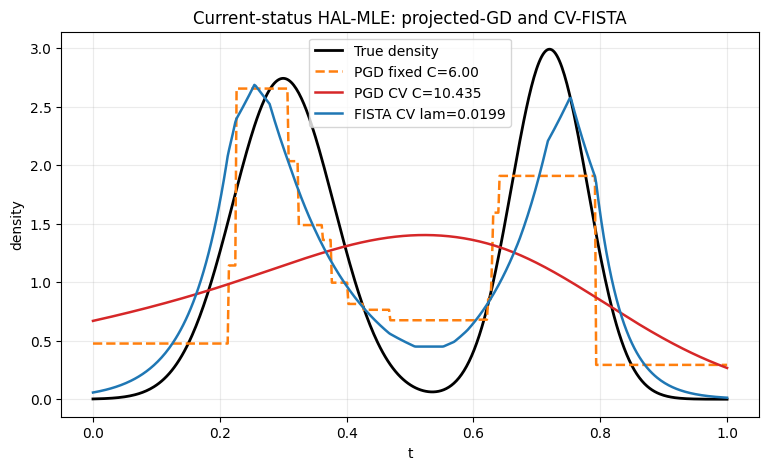

,model,value,KL(true || estimated)
0,PGD fixed C,6.000000,0.186735
1,PGD CV C,10.435110,0.453148
2,FISTA CV lam,0.019919,0.081172


In [11]:
# Compare current-status densities (PGD + CV-FISTA)
cs_grid = np.linspace(0.0, 1.0, 500)
cs_true_density = sampler.compute_density(cs_grid)
cs_fixed_density = pgd_cs_fixed.get_density_at_points(cs_grid)
cs_cv_density = pgd_cs_cv.get_density_at_points(cs_grid)
cs_fista_cv_density = fista_cs_cv.get_density_at_points(cs_grid)

plt.figure(figsize=(9, 5))
plt.plot(cs_grid, cs_true_density, "k-", lw=2, label="True density")
plt.plot(cs_grid, cs_fixed_density, "tab:orange", lw=1.8, linestyle="--", label=f"PGD fixed C={cs_fixed_nc:.2f}")
plt.plot(cs_grid, cs_cv_density, "tab:red", lw=1.8, label=f"PGD CV C={pgd_cs_cv_result.best_params['norm_constraint']:.3f}")
plt.plot(cs_grid, cs_fista_cv_density, "tab:blue", lw=1.8, label=f"FISTA CV lam={fista_cs_cv_result.best_params['lam']:.4f}")
plt.xlabel("t")
plt.ylabel("density")
plt.title("Current-status HAL-MLE: projected-GD and CV-FISTA")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

cs_grid_kl = np.linspace(0.0, 1.0, 2000)
cs_kl_fixed = float(kl_divergence(sampler.compute_density, cs_grid_kl, pgd_cs_fixed.get_density_at_points(cs_grid_kl)))
cs_kl_cv = float(kl_divergence(sampler.compute_density, cs_grid_kl, pgd_cs_cv.get_density_at_points(cs_grid_kl)))
cs_kl_fista_cv = float(kl_divergence(sampler.compute_density, cs_grid_kl, fista_cs_cv.get_density_at_points(cs_grid_kl)))

pd.DataFrame(
    {
        "model": ["PGD fixed C", "PGD CV C", "FISTA CV lam"],
        "value": [cs_fixed_nc, pgd_cs_cv_result.best_params["norm_constraint"], fista_cs_cv_result.best_params["lam"]],
        "KL(true || estimated)": [cs_kl_fixed, cs_kl_cv, cs_kl_fista_cv],
    }
)

## Optimization Diagnostics (Every 200 Iterations)

Using CV-selected hyperparameters, we refit with more iterations and track optimization history every 200 iterations.

Reported metrics:
- `log_likelihood`
- `l1_norm`
- `n_selected_points`

{'model': 'FISTA-IC', 'converged': True, 'n_iterations_run': 449, 'basis_order': 2, 'lam': 0.009005363030463742}


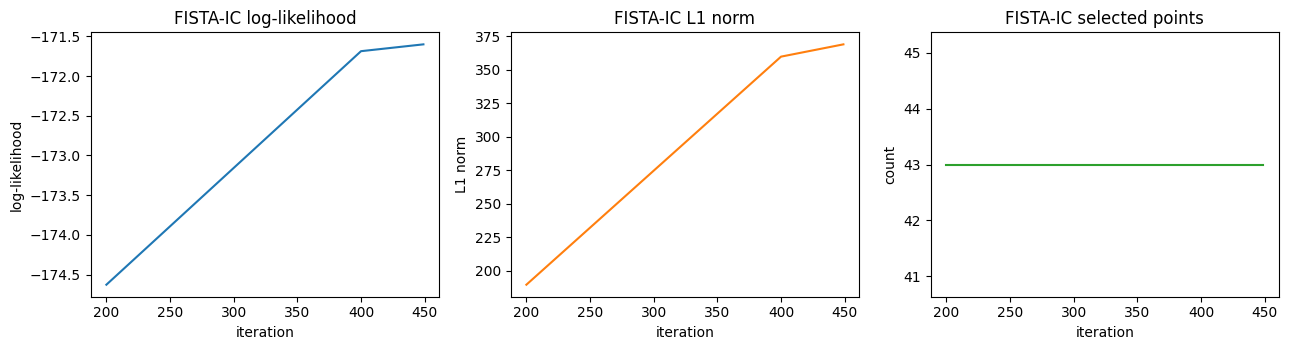

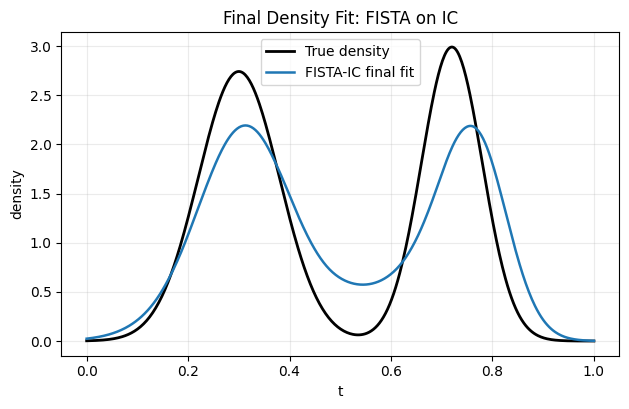

In [12]:
# Chunk 1: FISTA on interval-censored data (IC)

def history_df_from_results(results_dict: dict) -> pd.DataFrame:
    hist = results_dict.get("optimization_history", [])
    if len(hist) == 0:
        # Use explicit typed empty Series to keep static type checkers happy.
        return pd.DataFrame({
            "iteration": pd.Series(dtype="int64"),
            "log_likelihood": pd.Series(dtype="float64"),
            "l1_norm": pd.Series(dtype="float64"),
            "n_selected_points": pd.Series(dtype="int64"),
        })
    return pd.DataFrame(hist)

fista_ic_diag = IntervalCensoredFISTAEstimator(
    lam=float(cv_result.best_params["lam"]),
    basis_order=int(cv_result.best_params["basis_order"]),
    n_iterations=10000,
    tol=1e-6,
    ll_change_tol=1e-3,
    n_grid_points=300,
    initial_step=1.0,
    max_step=1.0,
    history_every=200,
)
fista_ic_diag.fit(ic_df, knot_strategy="turnbull")

fista_ic_diag_res = fista_ic_diag.get_results()
fista_ic_hist = history_df_from_results(fista_ic_diag_res)

print({
    "model": "FISTA-IC",
    "converged": fista_ic_diag_res["converged"],
    "n_iterations_run": fista_ic_diag_res["n_iterations_run"],
    "basis_order": cv_result.best_params["basis_order"],
    "lam": cv_result.best_params["lam"],
})

fista_ic_hist

if not fista_ic_hist.empty:
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
    axes[0].plot(fista_ic_hist["iteration"], fista_ic_hist["log_likelihood"], color="tab:blue")
    axes[0].set_title("FISTA-IC log-likelihood")
    axes[0].set_xlabel("iteration")
    axes[0].set_ylabel("log-likelihood")

    axes[1].plot(fista_ic_hist["iteration"], fista_ic_hist["l1_norm"], color="tab:orange")
    axes[1].set_title("FISTA-IC L1 norm")
    axes[1].set_xlabel("iteration")
    axes[1].set_ylabel("L1 norm")

    axes[2].plot(fista_ic_hist["iteration"], fista_ic_hist["n_selected_points"], color="tab:green")
    axes[2].set_title("FISTA-IC selected points")
    axes[2].set_xlabel("iteration")
    axes[2].set_ylabel("count")

    plt.tight_layout()
    plt.show()

# Final fit shape (IC)
grid_fit = np.linspace(0.0, 1.0, 500)
true_fit = sampler.compute_density(grid_fit)
est_fit = fista_ic_diag.get_density_at_points(grid_fit)

plt.figure(figsize=(7.2, 4.2))
plt.plot(grid_fit, true_fit, "k-", lw=2, label="True density")
plt.plot(grid_fit, est_fit, color="tab:blue", lw=1.8, label="FISTA-IC final fit")
plt.title("Final Density Fit: FISTA on IC")
plt.xlabel("t")
plt.ylabel("density")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

{'model': 'PGD-IC', 'converged': True, 'n_iterations_run': 910, 'basis_order': 0, 'norm_constraint': 5.607380433938585}


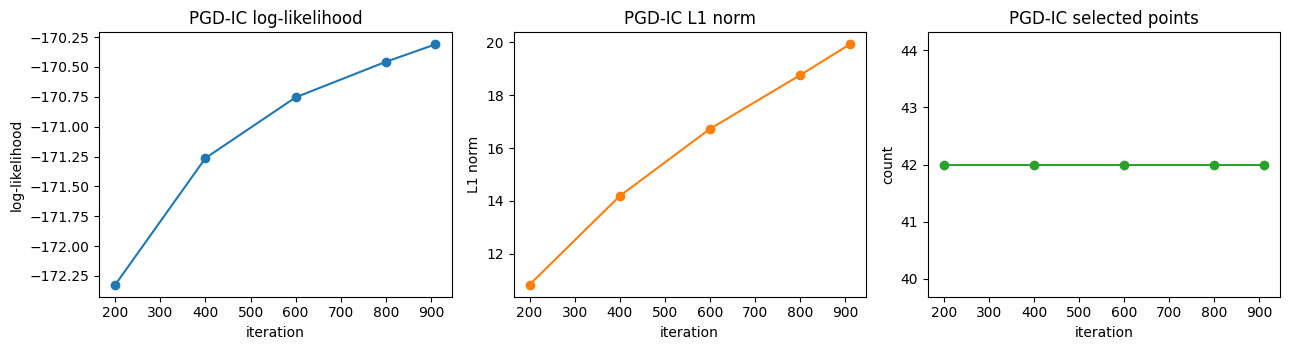

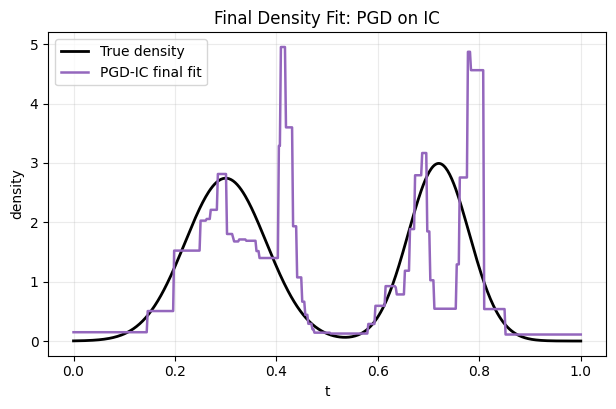

In [13]:
# Chunk 2: Projected-GD on interval-censored data (IC)
pgd_ic_diag = IntervalCensoredProjectedGDEstimator(
    #norm_constraint=float(pgd_cv_result.best_params["norm_constraint"]),
    norm_constraint=325,
    basis_order=int(pgd_cv_result.best_params["basis_order"]),
    learning_rate=0.05,
    use_nesterov=True,
    n_iterations=50000,
    tol=1e-6,
    ll_change_tol=5e-4,
    n_grid_points=300,
    history_every=200,
)
pgd_ic_diag.fit(ic_df, knot_strategy="turnbull")

pgd_ic_diag_res = pgd_ic_diag.get_results()
pgd_ic_hist = history_df_from_results(pgd_ic_diag_res)

print({
    "model": "PGD-IC",
    "converged": pgd_ic_diag_res["converged"],
    "n_iterations_run": pgd_ic_diag_res["n_iterations_run"],
    "basis_order": pgd_cv_result.best_params["basis_order"],
    "norm_constraint": pgd_cv_result.best_params["norm_constraint"],
})

pgd_ic_hist

if not pgd_ic_hist.empty:
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

    # Use markers so plots remain visible even when history has only 1-2 points.
    axes[0].plot(
        pgd_ic_hist["iteration"],
        pgd_ic_hist["log_likelihood"],
        color="tab:blue",
        marker="o",
        linestyle="-",
    )
    axes[0].set_title("PGD-IC log-likelihood")
    axes[0].set_xlabel("iteration")
    axes[0].set_ylabel("log-likelihood")

    axes[1].plot(
        pgd_ic_hist["iteration"],
        pgd_ic_hist["l1_norm"],
        color="tab:orange",
        marker="o",
        linestyle="-",
    )
    axes[1].set_title("PGD-IC L1 norm")
    axes[1].set_xlabel("iteration")
    axes[1].set_ylabel("L1 norm")

    axes[2].plot(
        pgd_ic_hist["iteration"],
        pgd_ic_hist["n_selected_points"],
        color="tab:green",
        marker="o",
        linestyle="-",
    )
    axes[2].set_title("PGD-IC selected points")
    axes[2].set_xlabel("iteration")
    axes[2].set_ylabel("count")

    if len(pgd_ic_hist) < 2:
        fig.suptitle("Only one history checkpoint recorded; increase n_iterations or reduce history_every")

    plt.tight_layout()
    plt.show()

# Final fit shape (IC)
grid_fit = np.linspace(0.0, 1.0, 500)
est_fit = np.asarray(pgd_ic_diag.get_density_at_points(grid_fit), dtype=float).ravel()

if not np.isfinite(est_fit).all():
    finite_mask = np.isfinite(est_fit)
    if finite_mask.any():
        lo = np.nanmin(est_fit[finite_mask])
        hi = np.nanmax(est_fit[finite_mask])
        est_fit = np.nan_to_num(est_fit, nan=lo, posinf=hi, neginf=lo)
    else:
        raise RuntimeError("PGD-IC produced all non-finite density values.")

plt.figure(figsize=(7.2, 4.2))
if "sampler" in globals():
    true_fit = sampler.compute_density(grid_fit)
    plt.plot(grid_fit, true_fit, "k-", lw=2, label="True density")

plt.plot(grid_fit, est_fit, color="tab:purple", lw=1.8, label="PGD-IC final fit")
plt.title("Final Density Fit: PGD on IC")
plt.xlabel("t")
plt.ylabel("density")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

{'model': 'FISTA-CS', 'converged': True, 'n_iterations_run': 452, 'basis_order': 1, 'lam': 0.019919137715298973}


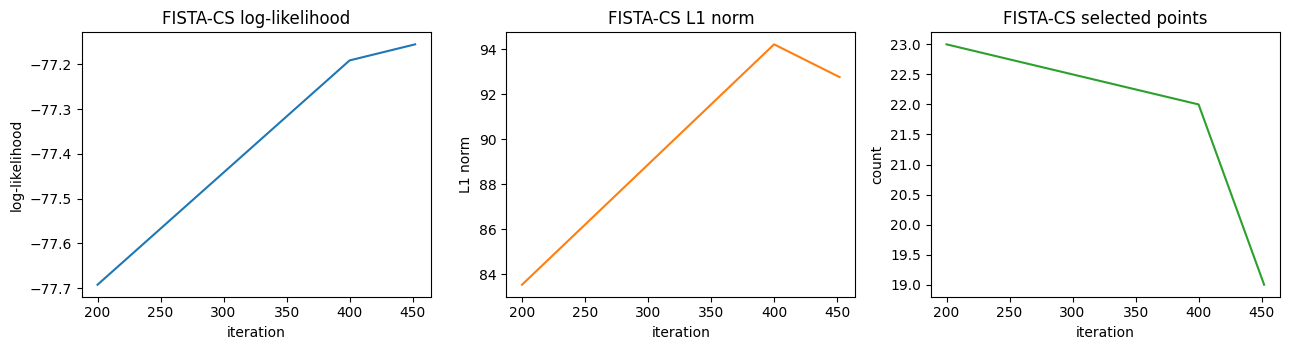

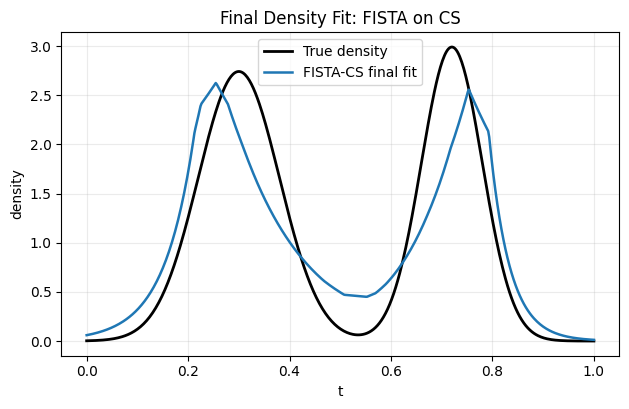

In [14]:
# Chunk 3: FISTA on current-status data (CS)
fista_cs_diag = IntervalCensoredFISTAEstimator(
    lam=float(fista_cs_cv_result.best_params["lam"]),
    basis_order=int(fista_cs_cv_result.best_params["basis_order"]),
    n_iterations=10000,
    tol=1e-6,
    ll_change_tol=1e-4,
    n_grid_points=260,
    initial_step=1.0,
    max_step=1.0,
    history_every=200,
)
fista_cs_diag.fit(cs_df, knot_strategy="turnbull")

fista_cs_diag_res = fista_cs_diag.get_results()
fista_cs_hist = history_df_from_results(fista_cs_diag_res)

print({
    "model": "FISTA-CS",
    "converged": fista_cs_diag_res["converged"],
    "n_iterations_run": fista_cs_diag_res["n_iterations_run"],
    "basis_order": fista_cs_cv_result.best_params["basis_order"],
    "lam": fista_cs_cv_result.best_params["lam"],
})

fista_cs_hist

if not fista_cs_hist.empty:
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
    axes[0].plot(fista_cs_hist["iteration"], fista_cs_hist["log_likelihood"], color="tab:blue")
    axes[0].set_title("FISTA-CS log-likelihood")
    axes[0].set_xlabel("iteration")
    axes[0].set_ylabel("log-likelihood")

    axes[1].plot(fista_cs_hist["iteration"], fista_cs_hist["l1_norm"], color="tab:orange")
    axes[1].set_title("FISTA-CS L1 norm")
    axes[1].set_xlabel("iteration")
    axes[1].set_ylabel("L1 norm")

    axes[2].plot(fista_cs_hist["iteration"], fista_cs_hist["n_selected_points"], color="tab:green")
    axes[2].set_title("FISTA-CS selected points")
    axes[2].set_xlabel("iteration")
    axes[2].set_ylabel("count")

    plt.tight_layout()
    plt.show()

# Final fit shape (CS)
grid_fit = np.linspace(0.0, 1.0, 500)
true_fit = sampler.compute_density(grid_fit)
est_fit = fista_cs_diag.get_density_at_points(grid_fit)

plt.figure(figsize=(7.2, 4.2))
plt.plot(grid_fit, true_fit, "k-", lw=2, label="True density")
plt.plot(grid_fit, est_fit, color="tab:blue", lw=1.8, label="FISTA-CS final fit")
plt.title("Final Density Fit: FISTA on CS")
plt.xlabel("t")
plt.ylabel("density")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

{'model': 'PGD-CS', 'converged': True, 'n_iterations_run': 12808, 'basis_order': 2, 'norm_constraint': 10.435109827473802}


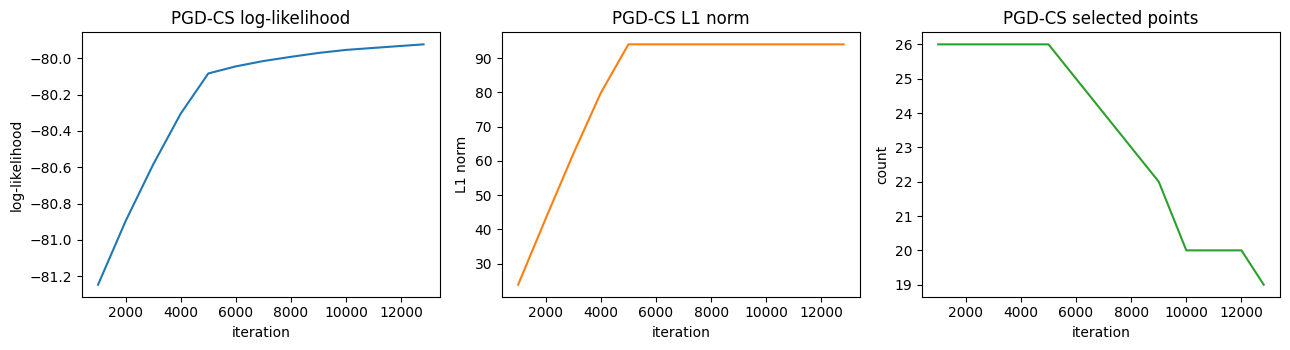

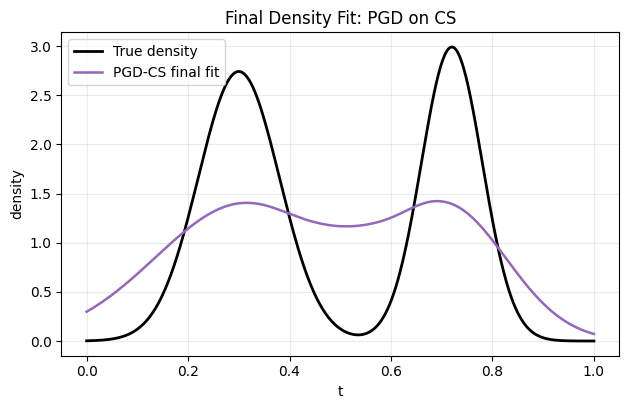

In [15]:
# Chunk 4: Projected-GD on current-status data (CS)
pgd_cs_diag = IntervalCensoredProjectedGDEstimator(
    #norm_constraint=float(pgd_cs_cv_result.best_params["norm_constraint"]),
    norm_constraint=94,
    basis_order=int(pgd_cs_cv_result.best_params["basis_order"]),
    learning_rate=0.05,
    use_nesterov=True,
    n_iterations=300000,
    tol=1e-6,
    ll_change_tol=1e-5,
    n_grid_points=260,
    history_every=1000,
)
pgd_cs_diag.fit(cs_df, knot_strategy="turnbull")

pgd_cs_diag_res = pgd_cs_diag.get_results()
pgd_cs_hist = history_df_from_results(pgd_cs_diag_res)

print({
    "model": "PGD-CS",
    "converged": pgd_cs_diag_res["converged"],
    "n_iterations_run": pgd_cs_diag_res["n_iterations_run"],
    "basis_order": pgd_cs_cv_result.best_params["basis_order"],
    "norm_constraint": pgd_cs_cv_result.best_params["norm_constraint"],
})

pgd_cs_hist

if not pgd_cs_hist.empty:
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
    axes[0].plot(pgd_cs_hist["iteration"], pgd_cs_hist["log_likelihood"], color="tab:blue")
    axes[0].set_title("PGD-CS log-likelihood")
    axes[0].set_xlabel("iteration")
    axes[0].set_ylabel("log-likelihood")

    axes[1].plot(pgd_cs_hist["iteration"], pgd_cs_hist["l1_norm"], color="tab:orange")
    axes[1].set_title("PGD-CS L1 norm")
    axes[1].set_xlabel("iteration")
    axes[1].set_ylabel("L1 norm")

    axes[2].plot(pgd_cs_hist["iteration"], pgd_cs_hist["n_selected_points"], color="tab:green")
    axes[2].set_title("PGD-CS selected points")
    axes[2].set_xlabel("iteration")
    axes[2].set_ylabel("count")

    plt.tight_layout()
    plt.show()

# Final fit shape (CS)
grid_fit = np.linspace(0.0, 1.0, 500)
true_fit = sampler.compute_density(grid_fit)
est_fit = pgd_cs_diag.get_density_at_points(grid_fit)

plt.figure(figsize=(7.2, 4.2))
plt.plot(grid_fit, true_fit, "k-", lw=2, label="True density")
plt.plot(grid_fit, est_fit, color="tab:purple", lw=1.8, label="PGD-CS final fit")
plt.title("Final Density Fit: PGD on CS")
plt.xlabel("t")
plt.ylabel("density")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## CV Log-Likelihood Shape vs L1 Constraint `M`

This section evaluates how the interval-censored CV incomplete log-likelihood changes as we vary the projected-GD L1 constraint radius `M` (holding other settings fixed).

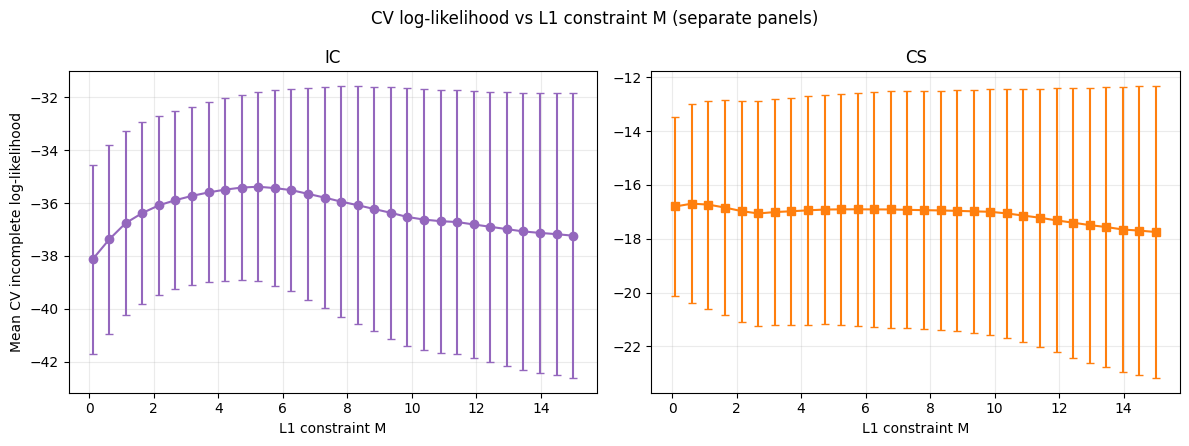

In [16]:
from sklearn.model_selection import KFold
from haldensity.censoring.interval.metrics import incomplete_loglik_interval

# Fix basis order to 0 for this shape analysis.
basis_order_for_shape = 0

# Grid of L1 constraints (M). Keep linear scale for this check.
M_grid = np.unique(np.concatenate([
    np.linspace(0.1, 15.0, 30),
]))


def compute_shape_curve(df: pd.DataFrame, *, m_grid: np.ndarray, random_state: int = 42) -> pd.DataFrame:
    kf = KFold(n_splits=5, shuffle=True, random_state=random_state)
    rows = []

    for M in m_grid:
        fold_ll = []
        for tr_idx, va_idx in kf.split(df):
            train_df = df.iloc[tr_idx].reset_index(drop=True)
            val_df = df.iloc[va_idx].reset_index(drop=True)

            est = IntervalCensoredProjectedGDEstimator(
                norm_constraint=float(M),
                basis_order=basis_order_for_shape,
                learning_rate=0.05,
                use_nesterov=True,
                n_iterations=10000,
                tol=1e-6,
                ll_change_tol=1e-4,
                n_grid_points=300,
            )
            est.fit(train_df, knot_strategy="turnbull")
            fold_ll.append(incomplete_loglik_interval(est, val_df, L_col="L", R_col="R"))

        rows.append({
            "M": float(M),
            "cv_ll_mean": float(np.mean(fold_ll)),
            "cv_ll_sd": float(np.std(fold_ll, ddof=1)) if len(fold_ll) > 1 else 0.0,
        })

    return pd.DataFrame(rows).sort_values("M").reset_index(drop=True)


# Compute IC and CS curves for parallel comparison.
shape_df_ic = compute_shape_curve(ic_df, m_grid=M_grid, random_state=42)
shape_df_cs = compute_shape_curve(cs_df, m_grid=M_grid, random_state=42)

shape_df_ic.head(), shape_df_cs.head()

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.5), sharey=False)

axes[0].errorbar(
    shape_df_ic["M"],
    shape_df_ic["cv_ll_mean"],
    yerr=shape_df_ic["cv_ll_sd"],
    fmt="o-",
    capsize=3,
    color="tab:purple",
)
axes[0].set_xlabel("L1 constraint M")
axes[0].set_ylabel("Mean CV incomplete log-likelihood")
axes[0].set_title("IC")
axes[0].grid(alpha=0.25)

axes[1].errorbar(
    shape_df_cs["M"],
    shape_df_cs["cv_ll_mean"],
    yerr=shape_df_cs["cv_ll_sd"],
    fmt="s-",
    capsize=3,
    color="tab:orange",
)
axes[1].set_xlabel("L1 constraint M")
axes[1].set_title("CS")
axes[1].grid(alpha=0.25)

fig.suptitle("CV log-likelihood vs L1 constraint M (separate panels)")
plt.tight_layout()
plt.show()

CS global-max M: 0.613793, CVLL=-16.694614, converged=True (iters=43)
CS local-max  M: 5.75172, CVLL=-16.906092, converged=True (iters=271)


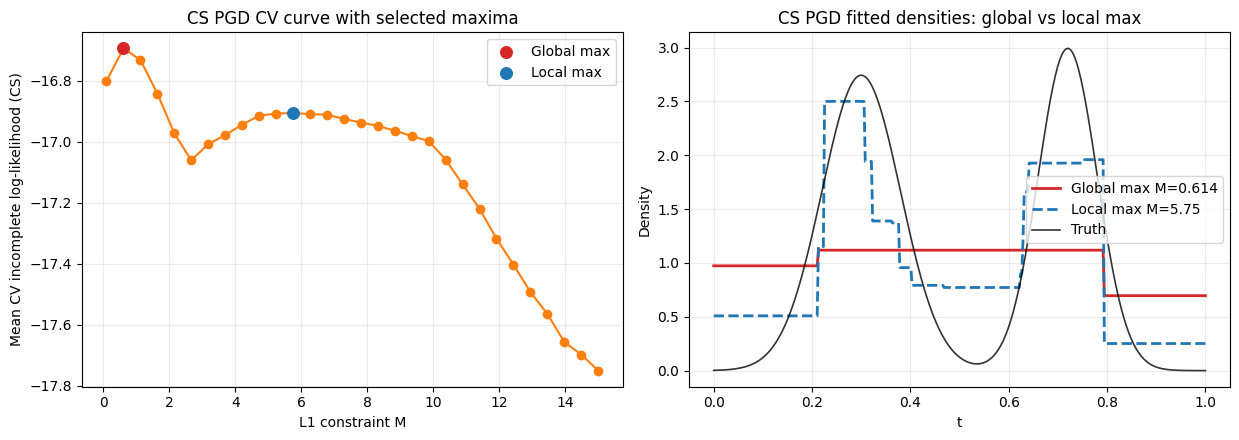

In [17]:
# Compare CS fits at global-max vs local-max M (from PGD CV curve)

x_cs_m = shape_df_cs["M"].to_numpy(dtype=float)
y_cs_m = shape_df_cs["cv_ll_mean"].to_numpy(dtype=float)

# Global maximum index on sampled M grid
global_idx_cs_m = int(np.nanargmax(y_cs_m))

# Local maxima on sampled grid (strict interior peaks)
local_peak_idxs_cs_m = [
    i for i in range(1, len(y_cs_m) - 1)
    if (y_cs_m[i] > y_cs_m[i - 1]) and (y_cs_m[i] > y_cs_m[i + 1])
]

# Pick best local peak different from global if available; otherwise fallback to 2nd best grid point
local_peak_idxs_cs_m = [i for i in local_peak_idxs_cs_m if i != global_idx_cs_m]
if local_peak_idxs_cs_m:
    local_idx_cs_m = max(local_peak_idxs_cs_m, key=lambda i: y_cs_m[i])
else:
    order_cs_m = np.argsort(y_cs_m)[::-1]
    local_idx_cs_m = int(order_cs_m[1]) if len(order_cs_m) > 1 else global_idx_cs_m

m_global_cs = float(x_cs_m[global_idx_cs_m])
m_local_cs = float(x_cs_m[local_idx_cs_m])


def fit_pgd_cs_at_m(m_val: float):
    est = IntervalCensoredProjectedGDEstimator(
        norm_constraint=float(m_val),
        basis_order=basis_order_for_shape,
        learning_rate=0.05,
        use_nesterov=True,
        n_iterations=10000,
        tol=1e-6,
        ll_change_tol=1e-4,
        n_grid_points=300,
    )
    est.fit(cs_df, knot_strategy="turnbull")
    return est


est_cs_global_m = fit_pgd_cs_at_m(m_global_cs)
est_cs_local_m = fit_pgd_cs_at_m(m_local_cs)

res_cs_global_m = est_cs_global_m.get_results()
res_cs_local_m = est_cs_local_m.get_results()

print(
    f"CS global-max M: {m_global_cs:.6g}, CVLL={y_cs_m[global_idx_cs_m]:.6f}, "
    f"converged={res_cs_global_m['converged']} (iters={res_cs_global_m['n_iterations_run']})"
)
print(
    f"CS local-max  M: {m_local_cs:.6g}, CVLL={y_cs_m[local_idx_cs_m]:.6f}, "
    f"converged={res_cs_local_m['converged']} (iters={res_cs_local_m['n_iterations_run']})"
)

x_grid_cs_m = np.linspace(0.0, 1.0, 400)
dens_cs_global_m = np.asarray(est_cs_global_m.get_density_at_points(x_grid_cs_m), dtype=float)
dens_cs_local_m = np.asarray(est_cs_local_m.get_density_at_points(x_grid_cs_m), dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))

# Left: CV curve with highlighted maxima
axes[0].plot(x_cs_m, y_cs_m, "o-", color="tab:orange", lw=1.5)
axes[0].scatter([m_global_cs], [y_cs_m[global_idx_cs_m]], color="tab:red", s=70, zorder=3, label="Global max")
axes[0].scatter([m_local_cs], [y_cs_m[local_idx_cs_m]], color="tab:blue", s=70, zorder=3, label="Local max")
axes[0].set_xlabel("L1 constraint M")
axes[0].set_ylabel("Mean CV incomplete log-likelihood (CS)")
axes[0].set_title("CS PGD CV curve with selected maxima")
axes[0].grid(alpha=0.25)
axes[0].legend()

# Right: fitted densities at those M values
axes[1].plot(x_grid_cs_m, dens_cs_global_m, color="tab:red", lw=2.0, label=f"Global max M={m_global_cs:.3g}")
axes[1].plot(x_grid_cs_m, dens_cs_local_m, color="tab:blue", lw=2.0, ls="--", label=f"Local max M={m_local_cs:.3g}")
if "sampler" in globals():
    axes[1].plot(x_grid_cs_m, sampler.compute_density(x_grid_cs_m), color="black", lw=1.2, alpha=0.8, label="Truth")
axes[1].set_xlabel("t")
axes[1].set_ylabel("Density")
axes[1].set_title("CS PGD fitted densities: global vs local max")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

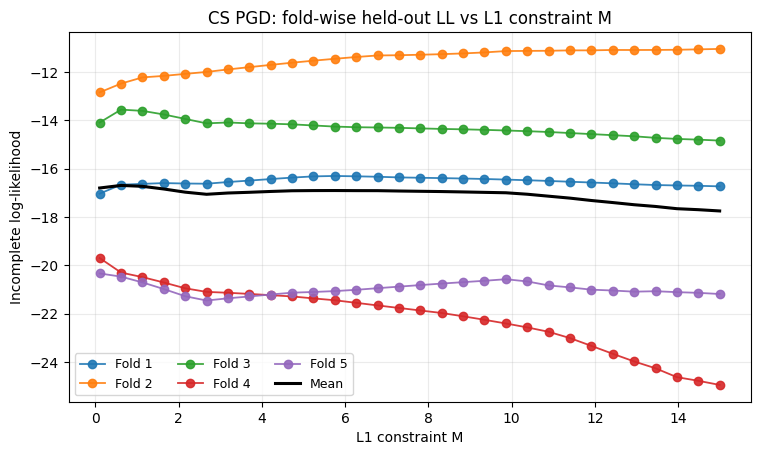

In [18]:
# Fold-wise LL vs L1 constraint M for CS (same PGD settings)

kf_cs = KFold(n_splits=5, shuffle=True, random_state=42)
splits_cs = list(kf_cs.split(cs_df))

fold_ll_curves_cs = np.full((len(splits_cs), len(M_grid)), np.nan, dtype=float)

for j, M in enumerate(M_grid):
    for fold_id, (tr_idx, va_idx) in enumerate(splits_cs):
        train_df = cs_df.iloc[tr_idx].reset_index(drop=True)
        val_df = cs_df.iloc[va_idx].reset_index(drop=True)

        est = IntervalCensoredProjectedGDEstimator(
            norm_constraint=float(M),
            basis_order=basis_order_for_shape,
            learning_rate=0.05,
            use_nesterov=True,
            n_iterations=10000,
            tol=1e-6,
            ll_change_tol=1e-4,
            n_grid_points=300,
        )
        est.fit(train_df, knot_strategy="turnbull")

        # Per-fold held-out LL (CV fold score)
        fold_ll_curves_cs[fold_id, j] = float(
            incomplete_loglik_interval(est, val_df, L_col="L", R_col="R")
        )

plt.figure(figsize=(8.8, 4.8))
for fold_id in range(fold_ll_curves_cs.shape[0]):
    plt.plot(
        M_grid,
        fold_ll_curves_cs[fold_id],
        marker="o",
        lw=1.3,
        alpha=0.9,
        label=f"Fold {fold_id + 1}",
    )

plt.plot(M_grid, np.mean(fold_ll_curves_cs, axis=0), color="black", lw=2.2, label="Mean")
plt.xlabel("L1 constraint M")
plt.ylabel("Incomplete log-likelihood")
plt.title("CS PGD: fold-wise held-out LL vs L1 constraint M")
plt.grid(alpha=0.25)
plt.legend(ncol=3, fontsize=9)
plt.show()

In [19]:
# Concavity check for fold-wise CS curves
# Discrete concavity criterion on sampled grid: second difference <= 0 (within tolerance).

tol = 1e-8
second_diff_cs = np.diff(fold_ll_curves_cs, n=2, axis=1)
nonconcave_mask_cs = np.any(second_diff_cs > tol, axis=1)

n_nonconcave = int(np.sum(nonconcave_mask_cs))
n_total = int(fold_ll_curves_cs.shape[0])

print(f"Nonconcave folds: {n_nonconcave}/{n_total}")
print("Per-fold nonconcave flags:", {f"Fold {i+1}": bool(nonconcave_mask_cs[i]) for i in range(n_total)})

# Optional: show the max second-difference per fold (positive means concavity violation)
max_second_diff_per_fold = np.max(second_diff_cs, axis=1)
print("Max second difference per fold:", {f"Fold {i+1}": float(max_second_diff_per_fold[i]) for i in range(n_total)})

Nonconcave folds: 5/5
Per-fold nonconcave flags: {'Fold 1': True, 'Fold 2': True, 'Fold 3': True, 'Fold 4': True, 'Fold 5': True}
Max second difference per fold: {'Fold 1': 0.07795344472977916, 'Fold 2': 0.02369945858224476, 'Fold 3': 0.21986105341186857, 'Fold 4': 0.4151791693279776, 'Fold 5': 0.2702664793516938}


IC global-max M: 5.23793, CVLL=-35.383915
IC local-max  M: 4.72414, CVLL=-35.415039


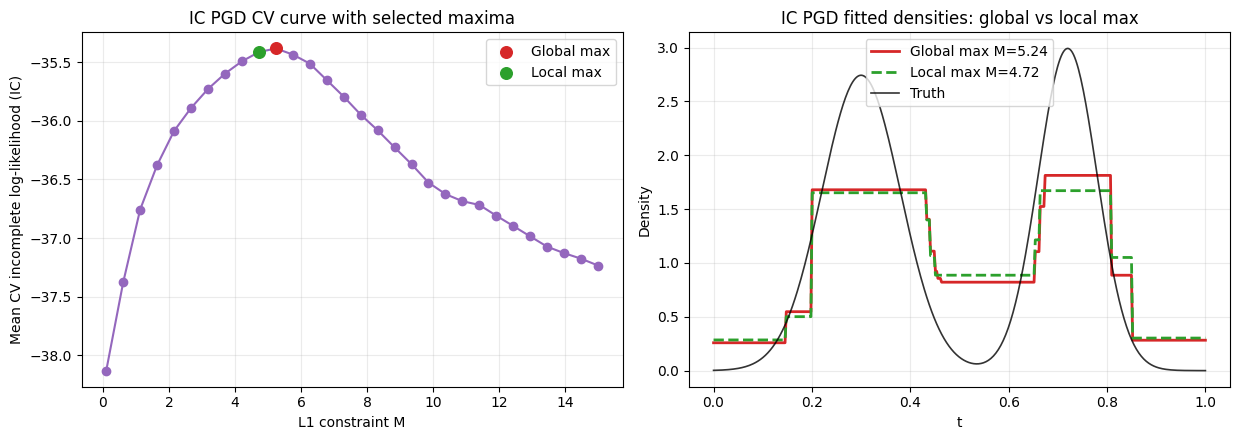

In [21]:
# Compare IC fits at global-max vs local-max M (from PGD CV curve)

x_ic_m = shape_df_ic["M"].to_numpy(dtype=float)
y_ic_m = shape_df_ic["cv_ll_mean"].to_numpy(dtype=float)

# Global maximum index on sampled M grid
global_idx_ic_m = int(np.nanargmax(y_ic_m))

# Local maxima on sampled grid (strict interior peaks)
local_peak_idxs_ic_m = [
    i for i in range(1, len(y_ic_m) - 1)
    if (y_ic_m[i] > y_ic_m[i - 1]) and (y_ic_m[i] > y_ic_m[i + 1])
]

# Pick best local peak different from global if available; otherwise fallback to 2nd best grid point
local_peak_idxs_ic_m = [i for i in local_peak_idxs_ic_m if i != global_idx_ic_m]
if local_peak_idxs_ic_m:
    local_idx_ic_m = max(local_peak_idxs_ic_m, key=lambda i: y_ic_m[i])
else:
    order_ic_m = np.argsort(y_ic_m)[::-1]
    local_idx_ic_m = int(order_ic_m[1]) if len(order_ic_m) > 1 else global_idx_ic_m

m_global_ic = float(x_ic_m[global_idx_ic_m])
m_local_ic = float(x_ic_m[local_idx_ic_m])

print(f"IC global-max M: {m_global_ic:.6g}, CVLL={y_ic_m[global_idx_ic_m]:.6f}")
print(f"IC local-max  M: {m_local_ic:.6g}, CVLL={y_ic_m[local_idx_ic_m]:.6f}")


def fit_pgd_ic_at_m(m_val: float):
    est = IntervalCensoredProjectedGDEstimator(
        norm_constraint=float(m_val),
        basis_order=basis_order_for_shape,
        learning_rate=0.05,
        use_nesterov=True,
        n_iterations=10000,
        tol=1e-6,
        ll_change_tol=1e-4,
        n_grid_points=300,
    )
    est.fit(ic_df, knot_strategy="turnbull")
    return est


est_ic_global_m = fit_pgd_ic_at_m(m_global_ic)
est_ic_local_m = fit_pgd_ic_at_m(m_local_ic)

x_grid_ic_m = np.linspace(0.0, 1.0, 400)
dens_ic_global_m = np.asarray(est_ic_global_m.get_density_at_points(x_grid_ic_m), dtype=float)
dens_ic_local_m = np.asarray(est_ic_local_m.get_density_at_points(x_grid_ic_m), dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))

# Left: CV curve with highlighted maxima
axes[0].plot(x_ic_m, y_ic_m, "o-", color="tab:purple", lw=1.5)
axes[0].scatter([m_global_ic], [y_ic_m[global_idx_ic_m]], color="tab:red", s=70, zorder=3, label="Global max")
axes[0].scatter([m_local_ic], [y_ic_m[local_idx_ic_m]], color="tab:green", s=70, zorder=3, label="Local max")
axes[0].set_xlabel("L1 constraint M")
axes[0].set_ylabel("Mean CV incomplete log-likelihood (IC)")
axes[0].set_title("IC PGD CV curve with selected maxima")
axes[0].grid(alpha=0.25)
axes[0].legend()

# Right: fitted densities at those M values
axes[1].plot(x_grid_ic_m, dens_ic_global_m, color="tab:red", lw=2.0, label=f"Global max M={m_global_ic:.3g}")
axes[1].plot(x_grid_ic_m, dens_ic_local_m, color="tab:green", lw=2.0, ls="--", label=f"Local max M={m_local_ic:.3g}")
if "sampler" in globals():
    axes[1].plot(x_grid_ic_m, sampler.compute_density(x_grid_ic_m), color="black", lw=1.2, alpha=0.8, label="Truth")
axes[1].set_xlabel("t")
axes[1].set_ylabel("Density")
axes[1].set_title("IC PGD fitted densities: global vs local max")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

Using fixed M = 0.613793

=== Restart/Convergence Summary ===
Total runs: 60
Converged runs: 60/60
Convergence rate: 1.000

=== Regret Summary (best-train proxy vs local converged runs) ===
Comparisons: 55
Mean delta_train: 0.000903
Median delta_train: 0.000036
Mean delta_valid: 0.000336
Median delta_valid: 0.000754
Valid win rate (delta_valid >= 0): 0.764


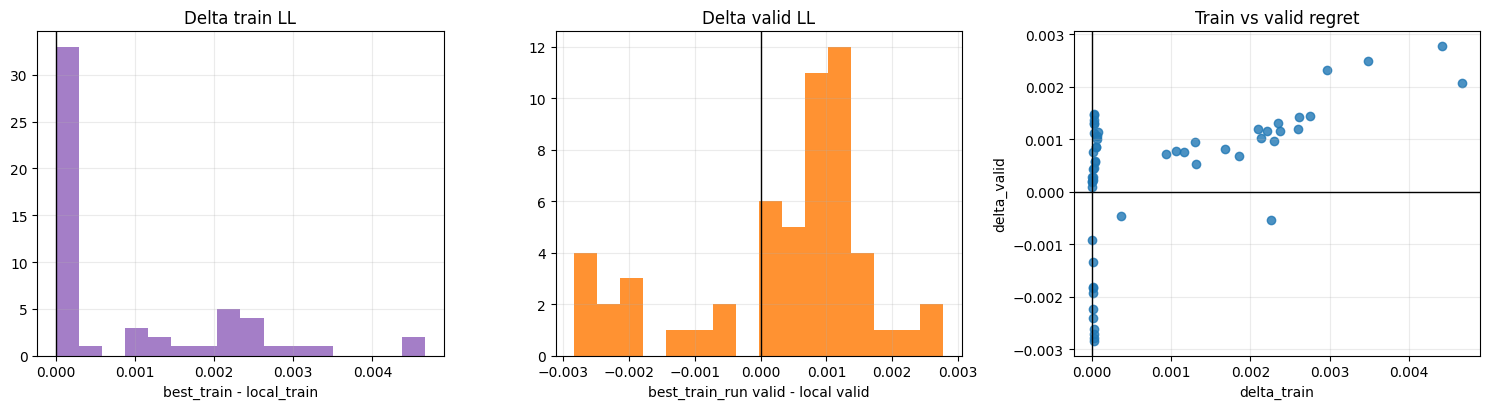


=== Density / KL Quality Summary ===
                               count      mean       std       min       25%  \
l1_density_diff_best_vs_local   55.0  0.000630  0.000589  0.000031  0.000228   
delta_kl_local_minus_best       55.0  0.000116  0.000196 -0.000102 -0.000007   

                                    50%       75%       max  
l1_density_diff_best_vs_local  0.000337  0.001086  0.002337  
delta_kl_local_minus_best      0.000017  0.000278  0.000680  


In [22]:
# Fixed-M local-vs-global (proxy) analysis for CS PGD via multi-restarts
# Idea:
# - Fix one M
# - Run many restarts (random warm starts, mixed Nesterov on/off)
# - Keep converged runs
# - Use best train LL among converged runs as a proxy for global optimum
# - Compute regret against each other converged local solution on train and held-out folds

M_fixed = float(m_global_cs) if "m_global_cs" in globals() else float(np.median(M_grid))
print(f"Using fixed M = {M_fixed:.6g}")

n_restarts = 12
warm_start_scale = 0.05
base_seed = 20260304

kf_fixed = KFold(n_splits=5, shuffle=True, random_state=42)
splits_fixed = list(kf_fixed.split(cs_df))

grid_eval = np.linspace(0.0, 1.0, 400)
true_density_eval = None
if "sampler" in globals():
    true_density_eval = np.asarray(sampler.compute_density(grid_eval), dtype=float)

run_rows = []
regret_rows = []
quality_rows = []

for fold_id, (tr_idx, va_idx) in enumerate(splits_fixed, start=1):
    train_df = cs_df.iloc[tr_idx].reset_index(drop=True)
    val_df = cs_df.iloc[va_idx].reset_index(drop=True)

    fold_runs = []
    theta_dim = None

    for r in range(n_restarts):
        rng = np.random.default_rng(base_seed + 1000 * fold_id + r)
        use_nesterov_r = bool(r % 2 == 0)  # alternate to diversify optimizer behavior

        warm_start = None
        if theta_dim is not None:
            warm_start = rng.normal(loc=0.0, scale=warm_start_scale, size=theta_dim)

        est = IntervalCensoredProjectedGDEstimator(
            norm_constraint=float(M_fixed),
            basis_order=basis_order_for_shape,
            learning_rate=0.05,
            use_nesterov=use_nesterov_r,
            n_iterations=10000,
            tol=1e-6,
            ll_change_tol=1e-4,
            n_grid_points=300,
        )

        fit_kwargs = {"knot_strategy": "turnbull"}
        if warm_start is not None:
            fit_kwargs["warm_start_theta"] = warm_start

        est.fit(train_df, **fit_kwargs)
        res = est.get_results()

        train_ll = float(incomplete_loglik_interval(est, train_df, L_col="L", R_col="R"))
        valid_ll = float(incomplete_loglik_interval(est, val_df, L_col="L", R_col="R"))

        theta_dim = int(est.theta_hat.size)

        row = {
            "fold": int(fold_id),
            "restart": int(r),
            "use_nesterov": bool(use_nesterov_r),
            "converged": bool(res["converged"]),
            "n_iterations_run": int(res["n_iterations_run"]),
            "train_ll": float(train_ll),
            "valid_ll": float(valid_ll),
            "estimator": est,
        }
        fold_runs.append(row)
        run_rows.append({k: v for k, v in row.items() if k != "estimator"})

    converged_runs = [rr for rr in fold_runs if rr["converged"]]
    if len(converged_runs) < 2:
        print(f"Fold {fold_id}: fewer than 2 converged runs; skipping regret comparison")
        continue

    best_run = max(converged_runs, key=lambda z: z["train_ll"])
    dens_best = np.asarray(best_run["estimator"].get_density_at_points(grid_eval), dtype=float)

    for rr in converged_runs:
        if rr["restart"] == best_run["restart"]:
            continue

        delta_train = float(best_run["train_ll"] - rr["train_ll"])
        delta_valid = float(best_run["valid_ll"] - rr["valid_ll"])

        regret_rows.append({
            "fold": int(fold_id),
            "best_restart": int(best_run["restart"]),
            "local_restart": int(rr["restart"]),
            "delta_train": delta_train,
            "delta_valid": delta_valid,
            "valid_win": bool(delta_valid >= 0.0),
        })

        dens_local = np.asarray(rr["estimator"].get_density_at_points(grid_eval), dtype=float)
        l1_diff = float(np.mean(np.abs(dens_best - dens_local)))

        qrow = {
            "fold": int(fold_id),
            "local_restart": int(rr["restart"]),
            "l1_density_diff_best_vs_local": l1_diff,
        }

        if true_density_eval is not None:
            eps = 1e-12
            kl_best = float(np.trapezoid(
                true_density_eval * np.log(np.maximum(true_density_eval, eps) / np.maximum(dens_best, eps)),
                grid_eval,
            ))
            kl_local = float(np.trapezoid(
                true_density_eval * np.log(np.maximum(true_density_eval, eps) / np.maximum(dens_local, eps)),
                grid_eval,
            ))
            qrow["kl_best"] = kl_best
            qrow["kl_local"] = kl_local
            qrow["delta_kl_local_minus_best"] = float(kl_local - kl_best)

        quality_rows.append(qrow)

run_df = pd.DataFrame(run_rows)
regret_df = pd.DataFrame(regret_rows)
quality_df = pd.DataFrame(quality_rows)

print("\n=== Restart/Convergence Summary ===")
print(f"Total runs: {len(run_df)}")
print(f"Converged runs: {int(run_df['converged'].sum())}/{len(run_df)}")
print(f"Convergence rate: {float(run_df['converged'].mean()):.3f}")

if len(regret_df) == 0:
    print("\nNo regret comparisons available (not enough converged runs per fold).")
else:
    print("\n=== Regret Summary (best-train proxy vs local converged runs) ===")
    print(f"Comparisons: {len(regret_df)}")
    print(f"Mean delta_train: {regret_df['delta_train'].mean():.6f}")
    print(f"Median delta_train: {regret_df['delta_train'].median():.6f}")
    print(f"Mean delta_valid: {regret_df['delta_valid'].mean():.6f}")
    print(f"Median delta_valid: {regret_df['delta_valid'].median():.6f}")
    print(f"Valid win rate (delta_valid >= 0): {regret_df['valid_win'].mean():.3f}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

    axes[0].hist(regret_df["delta_train"], bins=16, color="tab:purple", alpha=0.85)
    axes[0].axvline(0.0, color="black", lw=1.0)
    axes[0].set_title("Delta train LL")
    axes[0].set_xlabel("best_train - local_train")
    axes[0].grid(alpha=0.25)

    axes[1].hist(regret_df["delta_valid"], bins=16, color="tab:orange", alpha=0.85)
    axes[1].axvline(0.0, color="black", lw=1.0)
    axes[1].set_title("Delta valid LL")
    axes[1].set_xlabel("best_train_run valid - local valid")
    axes[1].grid(alpha=0.25)

    axes[2].scatter(regret_df["delta_train"], regret_df["delta_valid"], alpha=0.8, color="tab:blue")
    axes[2].axhline(0.0, color="black", lw=1.0)
    axes[2].axvline(0.0, color="black", lw=1.0)
    axes[2].set_title("Train vs valid regret")
    axes[2].set_xlabel("delta_train")
    axes[2].set_ylabel("delta_valid")
    axes[2].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

if len(quality_df) > 0:
    print("\n=== Density / KL Quality Summary ===")
    cols_to_show = ["l1_density_diff_best_vs_local"]
    if "delta_kl_local_minus_best" in quality_df.columns:
        cols_to_show.append("delta_kl_local_minus_best")
    print(quality_df[cols_to_show].describe().T)

## CV Log-Likelihood Shape vs FISTA `lambda`

This section evaluates interval-censored CV incomplete log-likelihood across a grid of FISTA regularization values `lambda`.

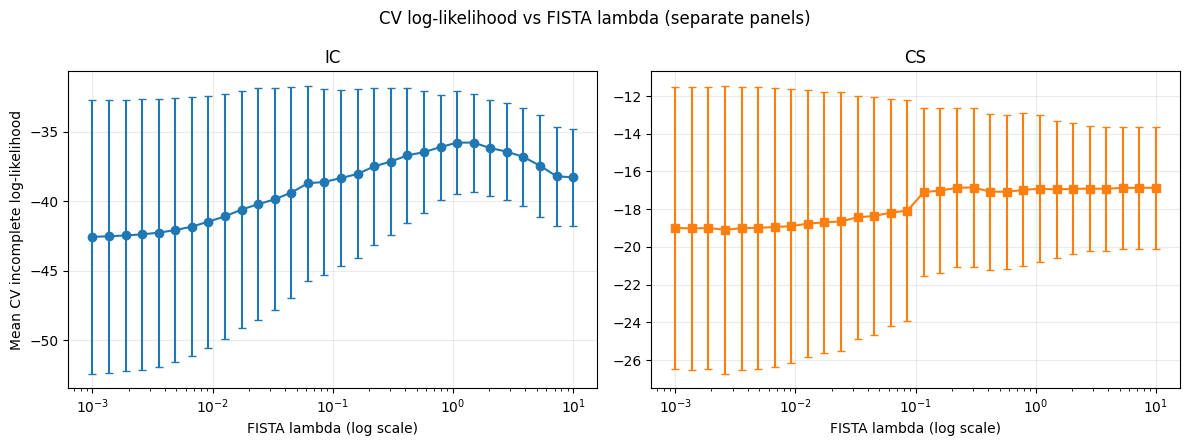

In [23]:
# CV log-likelihood vs FISTA lambda

lambda_grid = np.geomspace(1e-3, 1e1, 30)
# Fix basis order to 0 for this shape analysis.
basis_order_for_lambda = 0


def compute_lambda_curve(df: pd.DataFrame, *, lam_grid: np.ndarray, random_state: int = 42) -> pd.DataFrame:
    kf = KFold(n_splits=5, shuffle=True, random_state=random_state)
    rows_lam = []

    for lam in lam_grid:
        fold_ll = []
        for tr_idx, va_idx in kf.split(df):
            train_df = df.iloc[tr_idx].reset_index(drop=True)
            val_df = df.iloc[va_idx].reset_index(drop=True)

            est = IntervalCensoredFISTAEstimator(
                lam=float(lam),
                basis_order=basis_order_for_lambda,
                n_iterations=2000,
                tol=1e-6,
                ll_change_tol=1e-3,
                n_grid_points=300,
                initial_step=1.0,
                max_step=1.0,
            )
            est.fit(train_df, knot_strategy="turnbull")
            fold_ll.append(incomplete_loglik_interval(est, val_df, L_col="L", R_col="R"))

        rows_lam.append({
            "lambda": float(lam),
            "cv_ll_mean": float(np.mean(fold_ll)),
            "cv_ll_sd": float(np.std(fold_ll, ddof=1)) if len(fold_ll) > 1 else 0.0,
        })

    return pd.DataFrame(rows_lam).sort_values("lambda").reset_index(drop=True)


# Compute IC and CS lambda curves for parallel comparison.
shape_lam_df_ic = compute_lambda_curve(ic_df, lam_grid=lambda_grid, random_state=42)
shape_lam_df_cs = compute_lambda_curve(cs_df, lam_grid=lambda_grid, random_state=42)

shape_lam_df_ic.head(), shape_lam_df_cs.head()

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.5), sharey=False)

axes[0].errorbar(
    shape_lam_df_ic["lambda"],
    shape_lam_df_ic["cv_ll_mean"],
    yerr=shape_lam_df_ic["cv_ll_sd"],
    fmt="o-",
    capsize=3,
    color="tab:blue",
)
axes[0].set_xscale("log")
axes[0].set_xlabel("FISTA lambda (log scale)")
axes[0].set_ylabel("Mean CV incomplete log-likelihood")
axes[0].set_title("IC")
axes[0].grid(alpha=0.25)

axes[1].errorbar(
    shape_lam_df_cs["lambda"],
    shape_lam_df_cs["cv_ll_mean"],
    yerr=shape_lam_df_cs["cv_ll_sd"],
    fmt="s-",
    capsize=3,
    color="tab:orange",
)
axes[1].set_xscale("log")
axes[1].set_xlabel("FISTA lambda (log scale)")
axes[1].set_title("CS")
axes[1].grid(alpha=0.25)

fig.suptitle("CV log-likelihood vs FISTA lambda (separate panels)")
plt.tight_layout()
plt.show()

CS global-max lambda: 0.30392, CVLL=-16.851593
CS local-max  lambda: 1.08264, CVLL=-16.911411


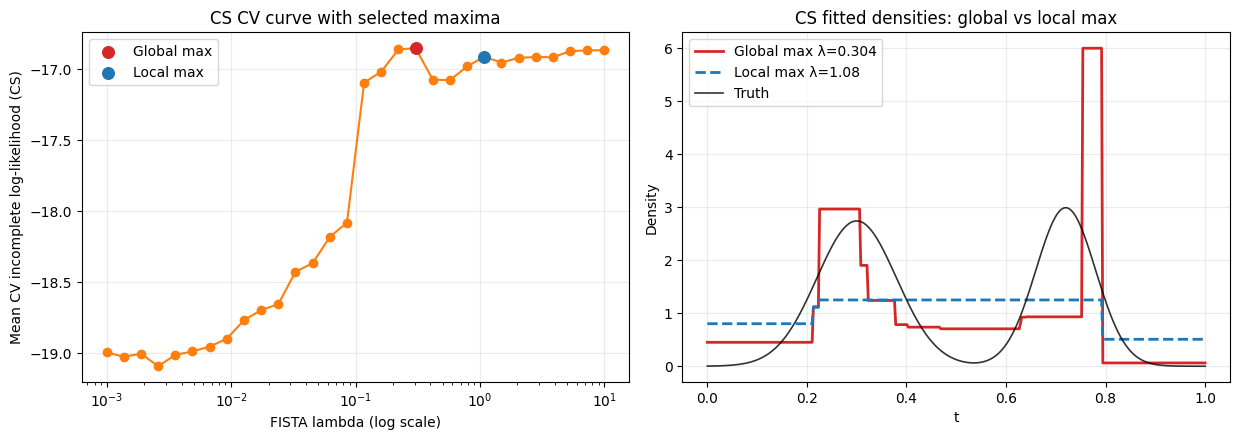

In [24]:
# Compare CS fits at global-max vs local-max lambda (from FISTA CV curve)

x_cs = shape_lam_df_cs["lambda"].to_numpy(dtype=float)
y_cs = shape_lam_df_cs["cv_ll_mean"].to_numpy(dtype=float)

# Global maximum index on the sampled lambda grid
global_idx = int(np.nanargmax(y_cs))

# Local maxima on the sampled grid (strict interior peaks)
local_peak_idxs = [
    i for i in range(1, len(y_cs) - 1)
    if (y_cs[i] > y_cs[i - 1]) and (y_cs[i] > y_cs[i + 1])
]

# Pick the best local peak different from global if available; otherwise fallback to 2nd best grid point
local_peak_idxs = [i for i in local_peak_idxs if i != global_idx]
if local_peak_idxs:
    local_idx = max(local_peak_idxs, key=lambda i: y_cs[i])
else:
    order = np.argsort(y_cs)[::-1]
    local_idx = int(order[1]) if len(order) > 1 else global_idx

lam_global = float(x_cs[global_idx])
lam_local = float(x_cs[local_idx])

print(f"CS global-max lambda: {lam_global:.6g}, CVLL={y_cs[global_idx]:.6f}")
print(f"CS local-max  lambda: {lam_local:.6g}, CVLL={y_cs[local_idx]:.6f}")


def fit_fista_cs_at_lambda(lam: float):
    est = IntervalCensoredFISTAEstimator(
        lam=float(lam),
        basis_order=basis_order_for_lambda,
        n_iterations=2000,
        tol=1e-6,
        ll_change_tol=1e-3,
        n_grid_points=300,
        initial_step=1.0,
        max_step=1.0,
    )
    est.fit(cs_df, knot_strategy="turnbull")
    return est


est_cs_global = fit_fista_cs_at_lambda(lam_global)
est_cs_local = fit_fista_cs_at_lambda(lam_local)

x_grid = np.linspace(0.0, 1.0, 400)
dens_cs_global = np.asarray(est_cs_global.get_density_at_points(x_grid), dtype=float)
dens_cs_local = np.asarray(est_cs_local.get_density_at_points(x_grid), dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))

# Left: CV curve with highlighted maxima
axes[0].plot(x_cs, y_cs, "o-", color="tab:orange", lw=1.5)
axes[0].scatter([lam_global], [y_cs[global_idx]], color="tab:red", s=70, zorder=3, label="Global max")
axes[0].scatter([lam_local], [y_cs[local_idx]], color="tab:blue", s=70, zorder=3, label="Local max")
axes[0].set_xscale("log")
axes[0].set_xlabel("FISTA lambda (log scale)")
axes[0].set_ylabel("Mean CV incomplete log-likelihood (CS)")
axes[0].set_title("CS CV curve with selected maxima")
axes[0].grid(alpha=0.25)
axes[0].legend()

# Right: fitted densities at those lambdas
axes[1].plot(x_grid, dens_cs_global, color="tab:red", lw=2.0, label=f"Global max λ={lam_global:.3g}")
axes[1].plot(x_grid, dens_cs_local, color="tab:blue", lw=2.0, ls="--", label=f"Local max λ={lam_local:.3g}")
if "sampler" in globals():
    axes[1].plot(x_grid, sampler.compute_density(x_grid), color="black", lw=1.2, alpha=0.8, label="Truth")
axes[1].set_xlabel("t")
axes[1].set_ylabel("Density")
axes[1].set_title("CS fitted densities: global vs local max")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

IC global-max lambda: 1.48735, CVLL=-35.774430
IC local-max  lambda: 1.08264, CVLL=-35.777125


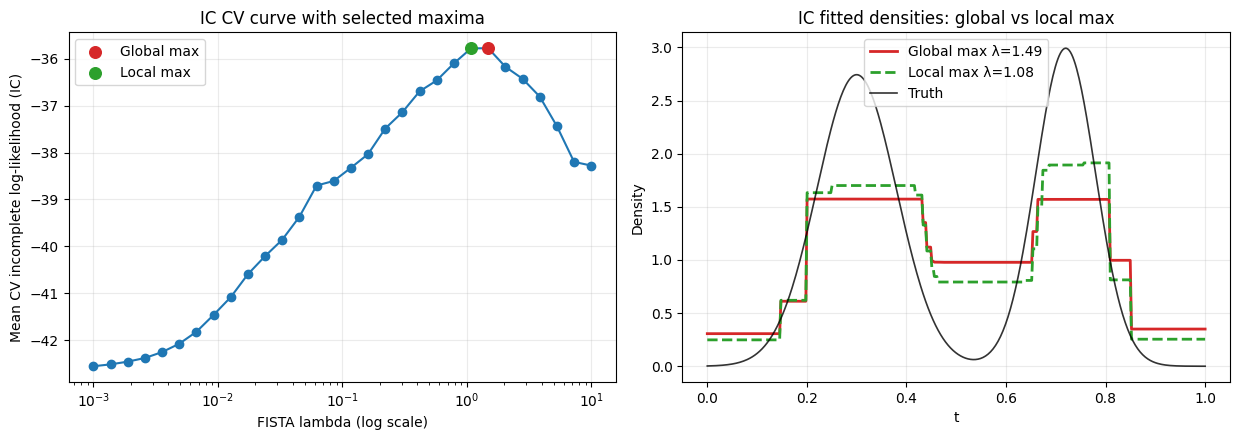

In [25]:
# Compare IC fits at global-max vs local-max lambda (from FISTA CV curve)

x_ic = shape_lam_df_ic["lambda"].to_numpy(dtype=float)
y_ic = shape_lam_df_ic["cv_ll_mean"].to_numpy(dtype=float)

# Global maximum index on the sampled lambda grid
global_idx_ic = int(np.nanargmax(y_ic))

# Local maxima on the sampled grid (strict interior peaks)
local_peak_idxs_ic = [
    i for i in range(1, len(y_ic) - 1)
    if (y_ic[i] > y_ic[i - 1]) and (y_ic[i] > y_ic[i + 1])
]

# Pick the best local peak different from global if available; otherwise fallback to 2nd best grid point
local_peak_idxs_ic = [i for i in local_peak_idxs_ic if i != global_idx_ic]
if local_peak_idxs_ic:
    local_idx_ic = max(local_peak_idxs_ic, key=lambda i: y_ic[i])
else:
    order_ic = np.argsort(y_ic)[::-1]
    local_idx_ic = int(order_ic[1]) if len(order_ic) > 1 else global_idx_ic

lam_global_ic = float(x_ic[global_idx_ic])
lam_local_ic = float(x_ic[local_idx_ic])

print(f"IC global-max lambda: {lam_global_ic:.6g}, CVLL={y_ic[global_idx_ic]:.6f}")
print(f"IC local-max  lambda: {lam_local_ic:.6g}, CVLL={y_ic[local_idx_ic]:.6f}")


def fit_fista_ic_at_lambda(lam: float):
    est = IntervalCensoredFISTAEstimator(
        lam=float(lam),
        basis_order=basis_order_for_lambda,
        n_iterations=2000,
        tol=1e-6,
        ll_change_tol=1e-3,
        n_grid_points=300,
        initial_step=1.0,
        max_step=1.0,
    )
    est.fit(ic_df, knot_strategy="turnbull")
    return est


est_ic_global = fit_fista_ic_at_lambda(lam_global_ic)
est_ic_local = fit_fista_ic_at_lambda(lam_local_ic)

x_grid_ic = np.linspace(0.0, 1.0, 400)
dens_ic_global = np.asarray(est_ic_global.get_density_at_points(x_grid_ic), dtype=float)
dens_ic_local = np.asarray(est_ic_local.get_density_at_points(x_grid_ic), dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))

# Left: CV curve with highlighted maxima
axes[0].plot(x_ic, y_ic, "o-", color="tab:blue", lw=1.5)
axes[0].scatter([lam_global_ic], [y_ic[global_idx_ic]], color="tab:red", s=70, zorder=3, label="Global max")
axes[0].scatter([lam_local_ic], [y_ic[local_idx_ic]], color="tab:green", s=70, zorder=3, label="Local max")
axes[0].set_xscale("log")
axes[0].set_xlabel("FISTA lambda (log scale)")
axes[0].set_ylabel("Mean CV incomplete log-likelihood (IC)")
axes[0].set_title("IC CV curve with selected maxima")
axes[0].grid(alpha=0.25)
axes[0].legend()

# Right: fitted densities at those lambdas
axes[1].plot(x_grid_ic, dens_ic_global, color="tab:red", lw=2.0, label=f"Global max λ={lam_global_ic:.3g}")
axes[1].plot(x_grid_ic, dens_ic_local, color="tab:green", lw=2.0, ls="--", label=f"Local max λ={lam_local_ic:.3g}")
if "sampler" in globals():
    axes[1].plot(x_grid_ic, sampler.compute_density(x_grid_ic), color="black", lw=1.2, alpha=0.8, label="Truth")
axes[1].set_xlabel("t")
axes[1].set_ylabel("Density")
axes[1].set_title("IC fitted densities: global vs local max")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

## Full Data CV Log-Likelihood vs L1 Bound `M`

Using the same DGP, we now treat `t_event` as fully observed (uncensored) data and evaluate K-fold CV log-likelihood against the L1 constraint upper bound `M`.

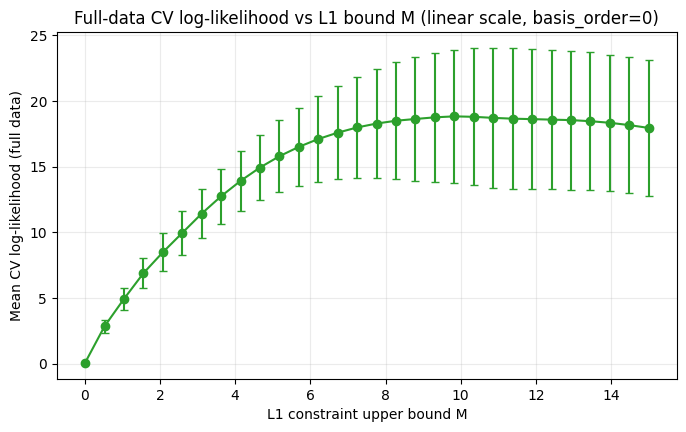

In [26]:
from haldensity.estimation import CVXPYEstimator

# Full (uncensored) sample from the same DGP.
# Use a larger n to reduce CV noise and recover the expected smooth shape.
n_full = 200
t_event_full = sampler.generate_samples(n_full)
full_df = pd.DataFrame({"W1": np.asarray(t_event_full, dtype=float).ravel()})

# Denser linear grid to match prior landscape exploration.
M_full_grid = np.linspace(0.01, 15.0, 30)
kf_full = KFold(n_splits=5, shuffle=True, random_state=42)
rows_full = []

for M in M_full_grid:
    fold_ll = []
    for tr_idx, va_idx in kf_full.split(full_df):
        train_df = full_df.iloc[tr_idx].reset_index(drop=True)
        val_df = full_df.iloc[va_idx].reset_index(drop=True)

        est = CVXPYEstimator(
            norm_constraint=float(M),
            basis_order=0,
            n_grid_points=300,
            tol=1e-6,
            solver="ECOS",
            use_secondary_solver=True,
            log_frequency=-1,
        )
        est.fit(train_df)
        x_val = np.asarray(val_df["W1"].values, dtype=float)
        dens_val = np.asarray(est.get_density_at_points(x_val), dtype=float)
        ll_val = float(np.sum(np.log(np.maximum(dens_val, 1e-12))))
        fold_ll.append(ll_val)

    rows_full.append({
        "M": float(M),
        "cv_ll_mean": float(np.mean(fold_ll)),
        "cv_ll_sd": float(np.std(fold_ll, ddof=1)) if len(fold_ll) > 1 else 0.0,
    })

full_shape_df = pd.DataFrame(rows_full).sort_values("M").reset_index(drop=True)
full_shape_df

plt.figure(figsize=(8.0, 4.5))
plt.errorbar(
    full_shape_df["M"],
    full_shape_df["cv_ll_mean"],
    yerr=full_shape_df["cv_ll_sd"],
    fmt="o-",
    capsize=3,
    color="tab:green",
)
plt.xlabel("L1 constraint upper bound M")
plt.ylabel("Mean CV log-likelihood (full data)")
plt.title("Full-data CV log-likelihood vs L1 bound M (linear scale, basis_order=0)")
plt.grid(alpha=0.25)
plt.show()